# SVM CV + SMOTE + Class Weight Assignment

This Colab notebook implements:

- Scaling only `BMI`, `MentHlth`, `PhysHlth`
- Scaler fitted on training data only and applied to test data
- Binary SVM RBF with CV tuning for `C` and `gamma`
- Comparison of SMOTE-inside-CV vs `class_weight='balanced'`
- Multiclass OvR SVM RBF with CV tuning
- Multiclass Linear vs RBF comparison
- Metrics, ROC curves, confusion matrices, saved models, final comparison table

In [ ]:
!pip -q install imbalanced-learn joblib

import os, shutil, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from google.colab import files
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.pipeline import Pipeline as SkPipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report,
    ConfusionMatrixDisplay, RocCurveDisplay
)

os.makedirs("reports", exist_ok=True)
os.makedirs("models", exist_ok=True)

print("Setup complete")

Setup complete


## Upload CSV files

In [ ]:
uploaded = files.upload()
print("Uploaded:", list(uploaded.keys()))

Saving binary_test.csv to binary_test.csv
Saving binary_train.csv to binary_train.csv
Saving multiclass_test.csv to multiclass_test.csv
Saving multiclass_train.csv to multiclass_train.csv
Uploaded: ['binary_test.csv', 'binary_train.csv', 'multiclass_test.csv', 'multiclass_train.csv']


## Load datasets

In [ ]:
binary_train = pd.read_csv("binary_train.csv")
binary_test = pd.read_csv("binary_test.csv")
multiclass_train = pd.read_csv("multiclass_train.csv")
multiclass_test = pd.read_csv("multiclass_test.csv")

BINARY_TARGET = "Diabetes_binary"

if "Diabetes_012" in multiclass_train.columns:
    MULTI_TARGET = "Diabetes_012"
elif "Class" in multiclass_train.columns:
    MULTI_TARGET = "Class"
else:
    raise ValueError("Multiclass target not found. Expected Diabetes_012 or Class.")

SCALE_COLS = ["BMI", "MentHlth", "PhysHlth"]

print("Binary train:", binary_train.shape)
print("Binary test:", binary_test.shape)
print("Multiclass train:", multiclass_train.shape)
print("Multiclass test:", multiclass_test.shape)
print("Multiclass target:", MULTI_TARGET)
print("Scaled columns:", SCALE_COLS)

Binary train: (202943, 22)
Binary test: (50737, 22)
Multiclass train: (202943, 22)
Multiclass test: (50737, 22)
Multiclass target: Diabetes_012
Scaled columns: ['BMI', 'MentHlth', 'PhysHlth']


## Optional stratified sampling

In [ ]:
USE_SAMPLE = True
TRAIN_SAMPLE_SIZE = 10000
TEST_SAMPLE_SIZE = 3000

def stratified_sample(df, target_col, n, random_state=123):
    if len(df) <= n:
        return df.copy().reset_index(drop=True)
    sampled = (
        df.groupby(target_col, group_keys=False)
          .apply(lambda x: x.sample(
              n=max(1, int(round(n * len(x) / len(df)))),
              random_state=random_state
          ))
    )
    return sampled.sample(frac=1, random_state=random_state).reset_index(drop=True)

if USE_SAMPLE:
    binary_train_run = stratified_sample(binary_train, BINARY_TARGET, TRAIN_SAMPLE_SIZE)
    binary_test_run = stratified_sample(binary_test, BINARY_TARGET, TEST_SAMPLE_SIZE)
    multiclass_train_run = stratified_sample(multiclass_train, MULTI_TARGET, TRAIN_SAMPLE_SIZE)
    multiclass_test_run = stratified_sample(multiclass_test, MULTI_TARGET, TEST_SAMPLE_SIZE)
else:
    binary_train_run = binary_train.copy()
    binary_test_run = binary_test.copy()
    multiclass_train_run = multiclass_train.copy()
    multiclass_test_run = multiclass_test.copy()

print("Binary train used:", binary_train_run.shape)
print("Binary test used:", binary_test_run.shape)
print("Multiclass train used:", multiclass_train_run.shape)
print("Multiclass test used:", multiclass_test_run.shape)

Binary train used: (10000, 22)
Binary test used: (3000, 22)
Multiclass train used: (10000, 22)
Multiclass test used: (2999, 22)


## Helper functions

In [ ]:
def split_xy(train_df, test_df, target_col):
    X_train = train_df.drop(columns=[target_col]).copy()
    y_train = train_df[target_col].copy()
    X_test = test_df.drop(columns=[target_col]).copy()
    y_test = test_df[target_col].copy()
    return X_train, y_train, X_test, y_test

def build_preprocessor(X_train):
    scale_cols_present = [c for c in SCALE_COLS if c in X_train.columns]
    other_cols = [c for c in X_train.columns if c not in scale_cols_present]
    return ColumnTransformer(
        transformers=[
            ("scale_selected", StandardScaler(), scale_cols_present),
            ("leave_unchanged", "passthrough", other_cols)
        ],
        remainder="drop"
    )

def confirm_train_only_scaling(X_train, X_test):
    scale_cols_present = [c for c in SCALE_COLS if c in X_train.columns]
    scaler = StandardScaler()
    scaler.fit(X_train[scale_cols_present])
    train_scaled = scaler.transform(X_train[scale_cols_present])
    test_scaled = scaler.transform(X_test[scale_cols_present])
    print("Scaler fitted on training data only")
    print("Scaled columns:", scale_cols_present)
    print("Train scaled means:", np.round(train_scaled.mean(axis=0), 6))
    print("Train scaled stds:", np.round(train_scaled.std(axis=0), 6))
    print("Test transformed means:", np.round(test_scaled.mean(axis=0), 6))

def binary_metrics(y_true, y_pred, y_prob):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_true, y_prob)
    }

def multiclass_metrics(y_true, y_pred, y_prob, classes):
    result = {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Macro F1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "Weighted F1": f1_score(y_true, y_pred, average="weighted", zero_division=0)
    }
    y_true_bin = label_binarize(y_true, classes=classes)
    auc_values = []
    for i, cls in enumerate(classes):
        if len(np.unique(y_true_bin[:, i])) < 2:
            auc_value = np.nan
        else:
            auc_value = roc_auc_score(y_true_bin[:, i], y_prob[:, i])
        auc_values.append(auc_value)
        result[f"X{cls} Precision"] = precision_score(y_true, y_pred, labels=[cls], average="macro", zero_division=0)
        result[f"X{cls} Recall"] = recall_score(y_true, y_pred, labels=[cls], average="macro", zero_division=0)
        result[f"X{cls} F1"] = f1_score(y_true, y_pred, labels=[cls], average="macro", zero_division=0)
        result[f"X{cls} AUC"] = auc_value
    result["Avg AUC"] = np.nanmean(auc_values)
    return result

def save_confusion_matrix(y_true, y_pred, title, path):
    fig, ax = plt.subplots(figsize=(6,5))
    ConfusionMatrixDisplay.from_predictions(y_true, y_pred, ax=ax, cmap="Blues", values_format="d")
    ax.set_title(title)
    plt.tight_layout()
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()

def save_binary_roc(y_true, y_prob, title, path):
    fig, ax = plt.subplots(figsize=(7,6))
    RocCurveDisplay.from_predictions(y_true, y_prob, ax=ax)
    ax.set_title(title)
    ax.grid(True)
    plt.tight_layout()
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()

def save_multiclass_roc(y_true, y_prob, classes, title, path):
    y_true_bin = label_binarize(y_true, classes=classes)
    plt.figure(figsize=(8,6))
    for i, cls in enumerate(classes):
        if len(np.unique(y_true_bin[:, i])) < 2:
            print("Skipping ROC for class", cls)
            continue
        RocCurveDisplay.from_predictions(y_true_bin[:, i], y_prob[:, i], name=f"Class {cls}")
    plt.title(title)
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()

## Binary SVM: RBF + Class Weight

In [ ]:
X_train_b, y_train_b, X_test_b, y_test_b = split_xy(binary_train_run, binary_test_run, BINARY_TARGET)
confirm_train_only_scaling(X_train_b, X_test_b)
preprocessor_b = build_preprocessor(X_train_b)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
binary_param_grid = {
    "svc__C": [0.1, 1, 10],
    "svc__gamma": ["scale", 0.01, 0.1]
}

binary_class_weight_pipeline = SkPipeline([
    ("preprocess", preprocessor_b),
    ("svc", SVC(kernel="rbf", class_weight="balanced", probability=True, random_state=123))
])

binary_class_weight_grid = GridSearchCV(
    binary_class_weight_pipeline,
    binary_param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

binary_class_weight_grid.fit(X_train_b, y_train_b)
print("Best params:", binary_class_weight_grid.best_params_)
print("Best CV F1:", binary_class_weight_grid.best_score_)

Scaler fitted on training data only
Scaled columns: ['BMI', 'MentHlth', 'PhysHlth']
Train scaled means: [-0.  0. -0.]
Train scaled stds: [1. 1. 1.]
Test transformed means: [0.013172 0.02248  0.059662]
Fitting 5 folds for each of 9 candidates, totalling 45 fits
Best params: {'svc__C': 10, 'svc__gamma': 0.01}
Best CV F1: 0.443498005531788


## Binary SVM: RBF + SMOTE inside CV

In [ ]:
binary_smote_pipeline = ImbPipeline([
    ("preprocess", preprocessor_b),
    ("smote", SMOTE(random_state=123)),
    ("svc", SVC(kernel="rbf", probability=True, random_state=123))
])

binary_smote_grid = GridSearchCV(
    binary_smote_pipeline,
    binary_param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

binary_smote_grid.fit(X_train_b, y_train_b)
print("Best params:", binary_smote_grid.best_params_)
print("Best CV F1:", binary_smote_grid.best_score_)

Fitting 5 folds for each of 9 candidates, totalling 45 fits
Best params: {'svc__C': 0.1, 'svc__gamma': 0.1}
Best CV F1: 0.43833556182829436


## Binary evaluation and selection


 Class Weight Balanced
              precision    recall  f1-score   support

           0       0.96      0.70      0.81      2582
           1       0.30      0.80      0.44       418

    accuracy                           0.71      3000
   macro avg       0.63      0.75      0.62      3000
weighted avg       0.87      0.71      0.76      3000



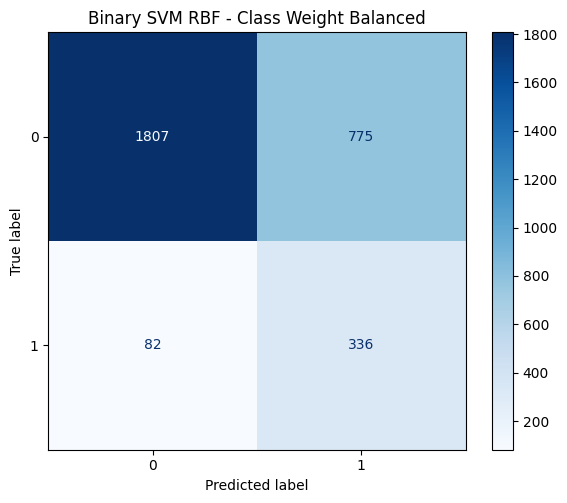

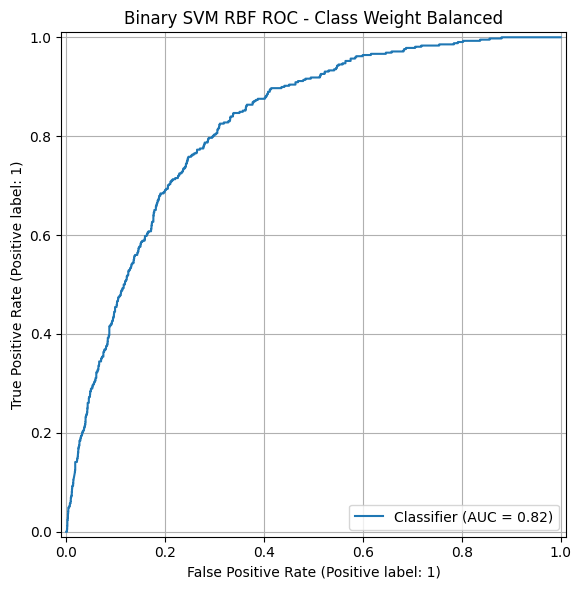


 SMOTE Inside CV
              precision    recall  f1-score   support

           0       0.95      0.72      0.82      2582
           1       0.30      0.75      0.43       418

    accuracy                           0.72      3000
   macro avg       0.63      0.74      0.62      3000
weighted avg       0.86      0.72      0.76      3000



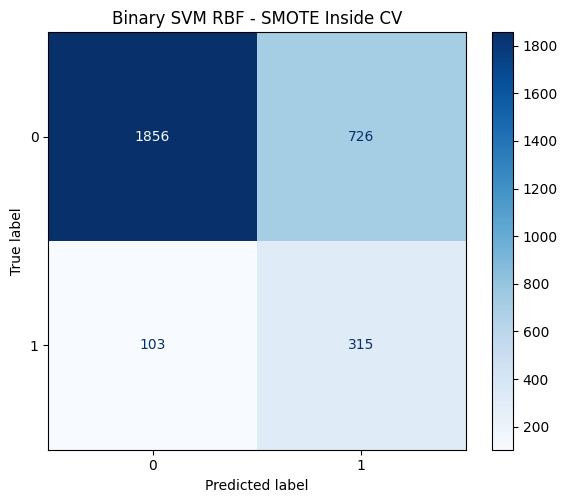

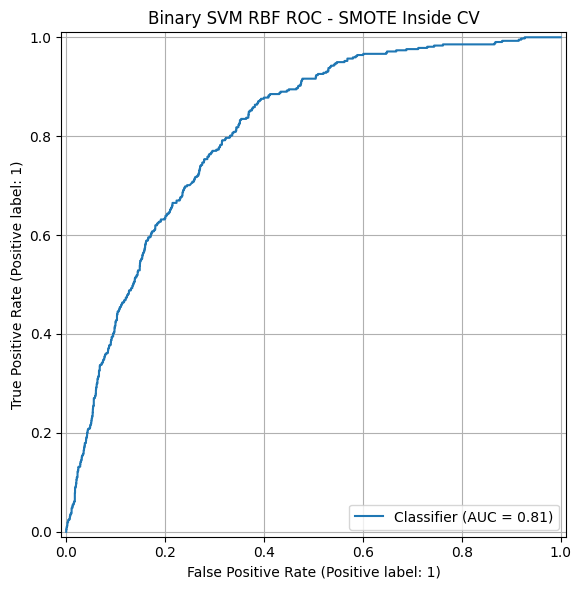

,Accuracy,Precision,Recall,F1,ROC_AUC,Dataset,Model,Imbalance Method,CV F1
0,0.714333,0.302430,0.803828,0.439503,0.822799,Binary,SVM RBF,Class Weight Balanced,0.443498
1,0.723667,0.302594,0.753589,0.431803,0.807595,Binary,SVM RBF,SMOTE Inside CV,0.438336


Selected binary approach: Class Weight Balanced


In [ ]:
binary_results = []

for method, model, cv_f1 in [
    ("Class Weight Balanced", binary_class_weight_grid.best_estimator_, binary_class_weight_grid.best_score_),
    ("SMOTE Inside CV", binary_smote_grid.best_estimator_, binary_smote_grid.best_score_)
]:
    y_pred = model.predict(X_test_b)
    y_prob = model.predict_proba(X_test_b)[:, 1]
    metrics = binary_metrics(y_test_b, y_pred, y_prob)
    metrics["Dataset"] = "Binary"
    metrics["Model"] = "SVM RBF"
    metrics["Imbalance Method"] = method
    metrics["CV F1"] = cv_f1
    binary_results.append(metrics)

    print("\n", method)
    print(classification_report(y_test_b, y_pred, zero_division=0))
    safe = method.replace(" ", "_")
    save_confusion_matrix(y_test_b, y_pred, f"Binary SVM RBF - {method}", f"reports/binary_cm_{safe}.png")
    save_binary_roc(y_test_b, y_prob, f"Binary SVM RBF ROC - {method}", f"reports/binary_roc_{safe}.png")

binary_results_df = pd.DataFrame(binary_results)
display(binary_results_df)

best_binary_row = binary_results_df.sort_values("CV F1", ascending=False).iloc[0]
best_binary_method = best_binary_row["Imbalance Method"]
best_binary_model = binary_class_weight_grid.best_estimator_ if best_binary_method == "Class Weight Balanced" else binary_smote_grid.best_estimator_

print("Selected binary approach:", best_binary_method)
joblib.dump(best_binary_model, "models/best_binary_svm_rbf.joblib")
binary_results_df.to_csv("reports/binary_svm_results.csv", index=False)

## Multiclass SVM: RBF + Class Weight

In [ ]:
X_train_m, y_train_m, X_test_m, y_test_m = split_xy(multiclass_train_run, multiclass_test_run, MULTI_TARGET)
confirm_train_only_scaling(X_train_m, X_test_m)
preprocessor_m = build_preprocessor(X_train_m)
multi_classes = sorted(y_train_m.unique())

multi_param_grid = {
    "svc__C": [0.1, 1, 10],
    "svc__gamma": ["scale", 0.01, 0.1]
}

multi_rbf_class_weight_pipeline = SkPipeline([
    ("preprocess", preprocessor_m),
    ("svc", SVC(kernel="rbf", class_weight="balanced", decision_function_shape="ovr", probability=True, random_state=123))
])

multi_rbf_class_weight_grid = GridSearchCV(
    multi_rbf_class_weight_pipeline,
    multi_param_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

multi_rbf_class_weight_grid.fit(X_train_m, y_train_m)
print("Best params:", multi_rbf_class_weight_grid.best_params_)
print("Best CV Macro F1:", multi_rbf_class_weight_grid.best_score_)

Scaler fitted on training data only
Scaled columns: ['BMI', 'MentHlth', 'PhysHlth']
Train scaled means: [-0.  0. -0.]
Train scaled stds: [1. 1. 1.]
Test transformed means: [ 0.002001 -0.00832   0.004332]
Fitting 5 folds for each of 9 candidates, totalling 45 fits
Best params: {'svc__C': 1, 'svc__gamma': 0.1}
Best CV Macro F1: 0.4109351311654069


## Multiclass SVM: RBF + SMOTE inside CV

In [ ]:
multi_rbf_smote_pipeline = ImbPipeline([
    ("preprocess", preprocessor_m),
    ("smote", SMOTE(random_state=123)),
    ("svc", SVC(kernel="rbf", decision_function_shape="ovr", probability=True, random_state=123))
])

multi_rbf_smote_grid = GridSearchCV(
    multi_rbf_smote_pipeline,
    multi_param_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

multi_rbf_smote_grid.fit(X_train_m, y_train_m)
print("Best params:", multi_rbf_smote_grid.best_params_)
print("Best CV Macro F1:", multi_rbf_smote_grid.best_score_)

Fitting 5 folds for each of 9 candidates, totalling 45 fits
Best params: {'svc__C': 1, 'svc__gamma': 0.1}
Best CV Macro F1: 0.41451606022907106


## Multiclass SVM: Linear kernel comparison

In [ ]:
linear_param_grid = {"svc__C": [0.1, 1, 10]}

multi_linear_pipeline = SkPipeline([
    ("preprocess", preprocessor_m),
    ("svc", SVC(kernel="linear", class_weight="balanced", decision_function_shape="ovr", probability=True, random_state=123))
])

multi_linear_grid = GridSearchCV(
    multi_linear_pipeline,
    linear_param_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

multi_linear_grid.fit(X_train_m, y_train_m)
print("Best params:", multi_linear_grid.best_params_)
print("Best CV Macro F1:", multi_linear_grid.best_score_)

Fitting 5 folds for each of 3 candidates, totalling 15 fits
Best params: {'svc__C': 0.1}
Best CV Macro F1: 0.41339081969439884


## Multiclass evaluation and selection


 SVM RBF - Class Weight Balanced
              precision    recall  f1-score   support

           0       0.92      0.71      0.80      2526
           1       0.03      0.13      0.05        55
           2       0.28      0.57      0.38       418

    accuracy                           0.68      2999
   macro avg       0.41      0.47      0.41      2999
weighted avg       0.82      0.68      0.73      2999



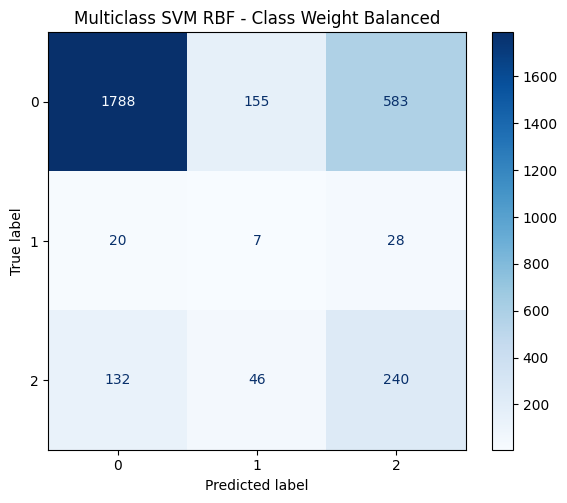

<Figure size 800x600 with 0 Axes>

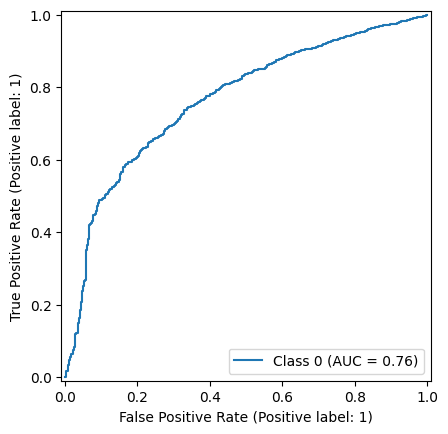

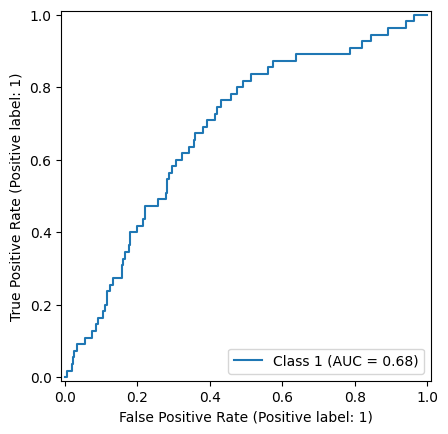

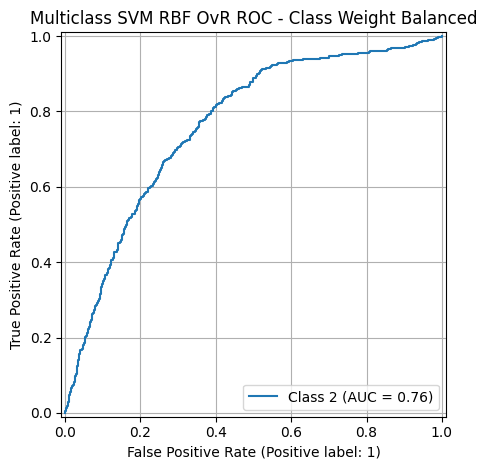


 SVM RBF - SMOTE Inside CV
              precision    recall  f1-score   support

           0       0.90      0.77      0.83      2526
           1       0.03      0.09      0.05        55
           2       0.29      0.46      0.35       418

    accuracy                           0.72      2999
   macro avg       0.41      0.44      0.41      2999
weighted avg       0.80      0.72      0.75      2999



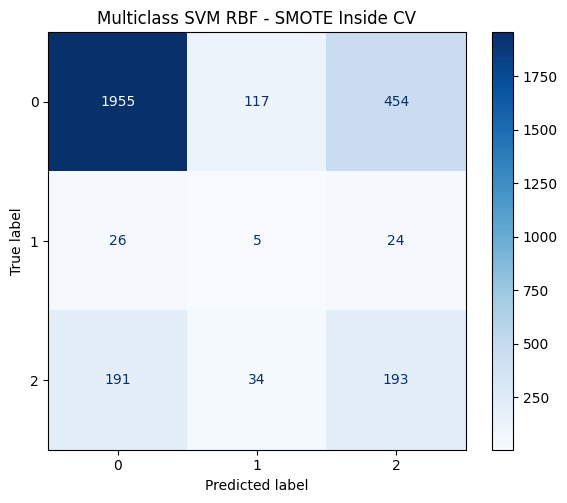

<Figure size 800x600 with 0 Axes>

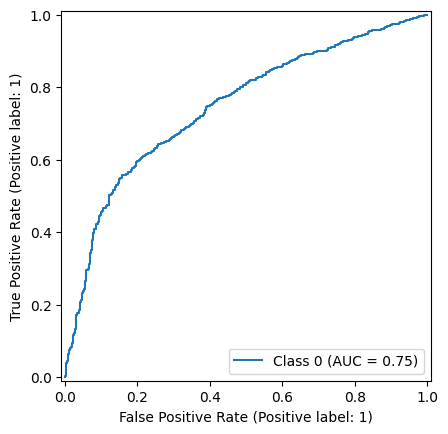

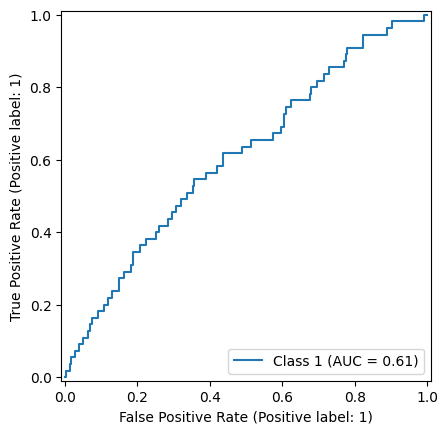

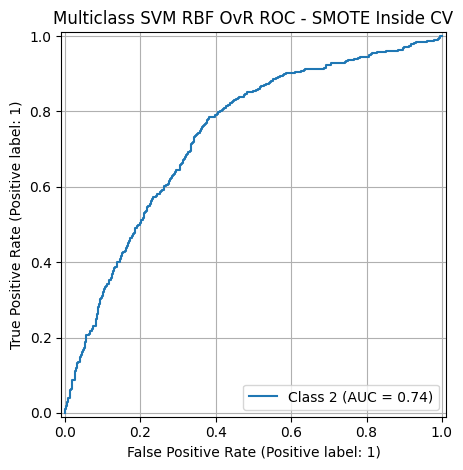


 SVM Linear - Class Weight Balanced
              precision    recall  f1-score   support

           0       0.93      0.65      0.77      2526
           1       0.03      0.33      0.06        55
           2       0.30      0.52      0.38       418

    accuracy                           0.63      2999
   macro avg       0.42      0.50      0.40      2999
weighted avg       0.83      0.63      0.70      2999



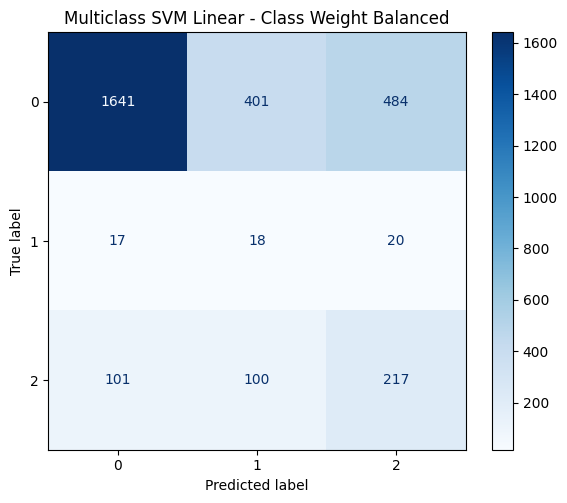

<Figure size 800x600 with 0 Axes>

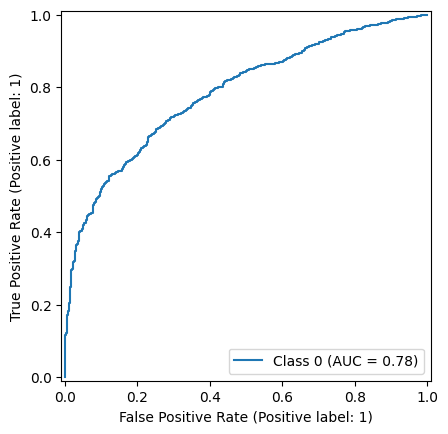

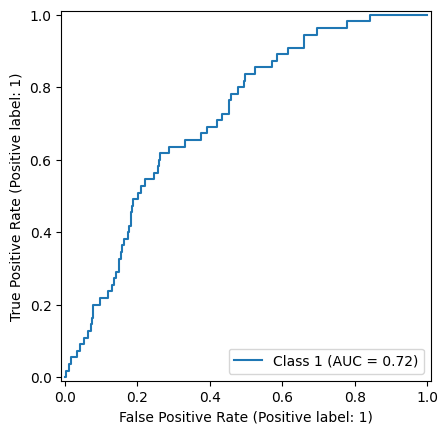

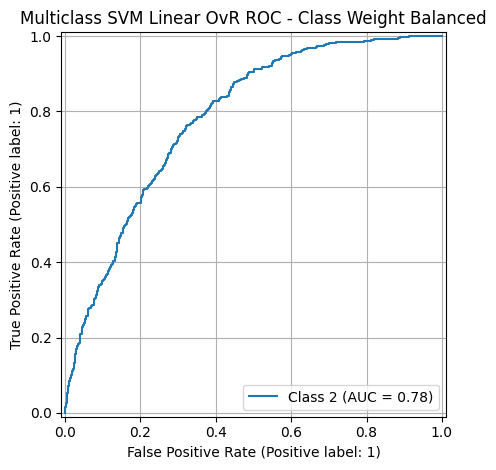

,Accuracy,Macro F1,Weighted F1,X0 Precision,X0 Recall,X0 F1,X0 AUC,X1 Precision,X1 Recall,X1 F1,X1 AUC,X2 Precision,X2 Recall,X2 F1,X2 AUC,Avg AUC,Dataset,Model,Imbalance Method,CV Macro F1
0,0.678560,0.410733,0.728125,0.921649,0.707838,0.800717,0.764382,0.033654,0.127273,0.053232,0.681448,0.282021,0.574163,0.378251,0.763886,0.736572,Multiclass,SVM RBF,Class Weight Balanced,0.410935
1,0.717906,0.411372,0.751277,0.900092,0.773951,0.832269,0.745624,0.032051,0.090909,0.047393,0.607751,0.287630,0.461722,0.354454,0.738488,0.697288,Multiclass,SVM RBF,SMOTE Inside CV,0.414516
2,0.625542,0.403227,0.699385,0.932916,0.649644,0.765928,0.784980,0.034682,0.327273,0.062718,0.715112,0.300971,0.519139,0.381036,0.784271,0.761454,Multiclass,SVM Linear,Class Weight Balanced,0.413391


Selected multiclass RBF approach: SMOTE Inside CV


In [ ]:
multiclass_results = []

for model_name, method, model, cv_macro_f1 in [
    ("SVM RBF", "Class Weight Balanced", multi_rbf_class_weight_grid.best_estimator_, multi_rbf_class_weight_grid.best_score_),
    ("SVM RBF", "SMOTE Inside CV", multi_rbf_smote_grid.best_estimator_, multi_rbf_smote_grid.best_score_),
    ("SVM Linear", "Class Weight Balanced", multi_linear_grid.best_estimator_, multi_linear_grid.best_score_)
]:
    y_pred = model.predict(X_test_m)
    y_prob = model.predict_proba(X_test_m)

    metrics = multiclass_metrics(y_test_m, y_pred, y_prob, multi_classes)
    metrics["Dataset"] = "Multiclass"
    metrics["Model"] = model_name
    metrics["Imbalance Method"] = method
    metrics["CV Macro F1"] = cv_macro_f1
    multiclass_results.append(metrics)

    print("\n", model_name, "-", method)
    print(classification_report(y_test_m, y_pred, zero_division=0))
    safe = f"{model_name}_{method}".replace(" ", "_")
    save_confusion_matrix(y_test_m, y_pred, f"Multiclass {model_name} - {method}", f"reports/multiclass_cm_{safe}.png")
    save_multiclass_roc(y_test_m, y_prob, multi_classes, f"Multiclass {model_name} OvR ROC - {method}", f"reports/multiclass_roc_{safe}.png")

multiclass_results_df = pd.DataFrame(multiclass_results)
display(multiclass_results_df)

best_rbf_row = multiclass_results_df[multiclass_results_df["Model"] == "SVM RBF"].sort_values("CV Macro F1", ascending=False).iloc[0]
best_multiclass_method = best_rbf_row["Imbalance Method"]
best_multiclass_rbf_model = multi_rbf_class_weight_grid.best_estimator_ if best_multiclass_method == "Class Weight Balanced" else multi_rbf_smote_grid.best_estimator_

print("Selected multiclass RBF approach:", best_multiclass_method)
joblib.dump(best_multiclass_rbf_model, "models/best_multiclass_svm_rbf.joblib")
joblib.dump(multi_linear_grid.best_estimator_, "models/multiclass_svm_linear.joblib")
multiclass_results_df.to_csv("reports/multiclass_svm_results.csv", index=False)

## Final comparison table vs baseline

In [ ]:
baseline_df = pd.DataFrame([
    {
        "Dataset": "Binary",
        "Model": "Logistic Regression Baseline",
        "Imbalance Method": "Class Weights",
        "Accuracy": 0.7310,
        "Precision": 0.3116,
        "Recall": 0.7692,
        "F1": 0.4435,
        "ROC_AUC": 0.8237
    }
])

comparison_table = pd.concat([baseline_df, binary_results_df, multiclass_results_df], ignore_index=True, sort=False)
display(comparison_table)
comparison_table.to_csv("reports/final_svm_comparison_table_vs_baseline.csv", index=False)
print("Saved comparison table")

,Dataset,Model,Imbalance Method,Accuracy,Precision,Recall,F1,ROC_AUC,CV F1,Macro F1,...,X1 Precision,X1 Recall,X1 F1,X1 AUC,X2 Precision,X2 Recall,X2 F1,X2 AUC,Avg AUC,CV Macro F1
0,Binary,Logistic Regression Baseline,Class Weights,0.731000,0.311600,0.769200,0.443500,0.823700,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Binary,SVM RBF,Class Weight Balanced,0.714333,0.302430,0.803828,0.439503,0.822799,0.443498,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Binary,SVM RBF,SMOTE Inside CV,0.723667,0.302594,0.753589,0.431803,0.807595,0.438336,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Multiclass,SVM RBF,Class Weight Balanced,0.678560,NaN,NaN,NaN,NaN,NaN,0.410733,...,0.033654,0.127273,0.053232,0.681448,0.282021,0.574163,0.378251,0.763886,0.736572,0.410935
4,Multiclass,SVM RBF,SMOTE Inside CV,0.717906,NaN,NaN,NaN,NaN,NaN,0.411372,...,0.032051,0.090909,0.047393,0.607751,0.287630,0.461722,0.354454,0.738488,0.697288,0.414516
5,Multiclass,SVM Linear,Class Weight Balanced,0.625542,NaN,NaN,NaN,NaN,NaN,0.403227,...,0.034682,0.327273,0.062718,0.715112,0.300971,0.519139,0.381036,0.784271,0.761454,0.413391


Saved comparison table


## Download deliverables

In [3]:
shutil.make_archive("svm_assignment_outputs", "zip", ".")
files.download("svm_assignment_outputs.zip")

NameError: name 'shutil' is not defined